# Sinusoid: benchmark of every method

Sweeps Unguided (temperature), FR, Bayesian FR, Random perturbations, AMG and Broken Memories at $N=20$: 100 samples x 50 paired repetitions per setting. Writes `all_figures/sinusoid_pareto_N20.pdf`, `all_figures/sinusoid_final_positions_N20.pdf` (at fidelity MSE $\le 2 \cdot 10^{-3}$), `cache/operating_points.json` and `cache/bm_stats.pt`.

In [1]:
import json, sys, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/guidance').exists())
sys.path.insert(0, str(ROOT / 'src'))
from models import sinusoid as S
from plotting import wsstyle

EXP = ROOT / 'experiments/sinusoid'
CACHE, RESULTS = EXP / 'cache', EXP / 'results'
CACHE.mkdir(exist_ok=True); RESULTS.mkdir(exist_ok=True)

RUN = True
N_VALUES = [20]
N_SAMPLES = 100
N_REPEATS = 50
SEEDS = [20260930 + i for i in range(N_REPEATS)]
UNGUIDED_TEMPERATURES = [0.8, 0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.15, 1.2]
ETAS = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2]
RANDOM_ETAS = ETAS + [1.4, 1.6, 1.8, 2]   # from 2.5 on samples leave the curve
# window: guided final fraction of sampling (default 0.2)
FR_WINDOWS = {w: [0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0, 1.2, 1.5] for w in [0.1, 0.3, 0.4, 0.6]}
TARGET_MEMORIZATION = 0.2
FIDELITY_BUDGET = 2e-3   # final positions: per method, the least memorized setting within this fidelity MSE
FIGURE_FR_WINDOW = 0.1   # final positions: FR variants guide the last 10% of sampling; longer windows drain the curve's ends
BAYES_ALPHAS = [0.5, 1, 2]   # Bayesian FR Dirichlet concentration, each a point set on the Pareto front
# AMG c3 has no published value here: below this range it does nothing, above it samples diverge.
AMG_C3 = {20: [0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3, 3.25, 3.5, 3.75, 4, 4.25, 4.5, 5, 5.5, 6, 6.5, 7, 7.5,
               10, 12.5, 15, 17.5, 20, 25, 30, 35, 40, 45]}
# AMG guided only for t/T <= window, which tolerates larger c3 (from 80 on samples leave the curve).
AMG_WINDOWS = {20: {w: [2, 5, 7.5, 10, 15, 20, 30, 40] for w in [0.2, 0.4, 0.6]}}
BM_THRESHOLD_SCALES = {20: [0.1, 0.6, 0.625, 0.65, 0.675, 0.7, 0.725, 0.75, 0.8, 0.85, 0.9, 1.0]}
# scales in (0.1, 0.6) are dominated by 0.1; that gap is covered by shorter durations at 0.1
BM_DURATIONS = {20: [190, 192, 194, 195, 196, 197, 198, 199]}
# Broken Memories beyond the paper: lower thresholds and narrower band gamma (paper: 3)
BM_LOW_SCALES = {20: [0.01, 0.02, 0.03, 0.05, 0.075]}
BM_GAMMAS = {20: {scale: [0.25, 0.5, 1, 2, 4, 6] for scale in [0.01, 0.02, 0.03, 0.05, 0.1, 0.2]}}

def sync(device):
    if device.type == 'cuda': torch.cuda.synchronize(device)
    if device.type == 'mps': torch.mps.synchronize()

def timed(run, fn):
    if run['device'].type == 'cuda': torch.cuda.reset_peak_memory_stats(run['device'])
    sync(run['device']); start = time.perf_counter(); x = fn(); sync(run['device'])
    peak = torch.cuda.max_memory_allocated(run['device']) / 2**20 if run['device'].type == 'cuda' else np.nan
    return x.cpu(), time.perf_counter() - start, peak

print(f'{N_SAMPLES} samples x {N_REPEATS} paired repetitions')

100 samples x 50 paired repetitions


## Model and metrics

Memorized: $d_1/d_2 < 1/3$, near-duplicate atoms (within 0.05) merged; fidelity: mean squared distance to the curve. All in `src/models/sinusoid.py`.

## Run the paired experiment

Samples are cached in `cache/benchmark_samples.pt` and only missing ones are drawn; metrics are recomputed from the cache into `results/runs.csv`.

In [2]:
_CACHE_SAMPLES = CACHE / 'benchmark_samples.pt'
_CACHE_BM = CACHE / 'bm_stats.pt'
_CACHE_CAL = RESULTS / 'calibration_cost.csv'

runs = {N: S.load(N) for N in N_VALUES}

AMG_FORM = 'paper: Eq. 8 differentiated in numerator and denominator'

samples, calibration_rows = {}, []
if _CACHE_SAMPLES.exists():
    samples = torch.load(_CACHE_SAMPLES, weights_only=False)
    stale = [k for k, v in samples.items() if v['family'] == 'AMG' and v.get('amg_form') != AMG_FORM]
    for k in stale: del samples[k]
    print(f'Loaded from cache: {len(samples)} sample sets; {len(stale)} stale AMG sets dropped.')
if _CACHE_CAL.exists() and _CACHE_CAL.stat().st_size > 1:
    calibration_rows = pd.read_csv(_CACHE_CAL).to_dict('records')
have = set(samples)
bm_stats_all = torch.load(_CACHE_BM, weights_only=False) if _CACHE_BM.exists() else {}

current = set()   # cached sets outside the current sweeps are kept but not evaluated

def record(run, repetition, seed, method, family, sweep, strength, fn, score_evals, **params):
    key = (run['N'], repetition, method); current.add(key)
    if key in have:
        samples[key]['params'] = params; return
    x, seconds, peak = timed(run, fn)
    samples[(run['N'], repetition, method)] = dict(x=x, seed=seed, family=family, sweep=sweep, strength=strength, seconds=seconds,
                                                   peak_gpu_mb=peak, score_evals_per_sample=score_evals,
                                                   amg_form=AMG_FORM if family == 'AMG' else None, params=params)
    have.add(key)

if RUN:
    n_before = len(samples)
    for N, run in runs.items():
        if N not in bm_stats_all:
            sync(run['device']); start=time.perf_counter(); bm_stats_all[N]=S.calibrate_bm(run); sync(run['device'])
            calibration_rows = [r for r in calibration_rows if r['N'] != N]
            calibration_rows.append(dict(N=N, method='Broken Memories calibration', seconds=time.perf_counter()-start, samples=512))
            torch.save(bm_stats_all, _CACHE_BM)
        bm_stats = bm_stats_all[N]
        for repetition, seed in enumerate(SEEDS):
            n_rep = len(samples)
            for temp in UNGUIDED_TEMPERATURES:
                record(run,repetition,seed,f'Unguided T={temp:g}','Unguided','temperature',temp,lambda t=temp:S.unguided(run,seed,N_SAMPLES,t),run['n_steps'],temperature=temp)
            for eta in ETAS:
                record(run,repetition,seed,f'Ambient FR eta={eta:g}','Ambient FR','eta',eta,lambda e=eta:S.fr(run,seed,N_SAMPLES,e),2*run['n_steps'],eta=eta)
                for a in BAYES_ALPHAS:
                    settings = {**S.FR_SETTINGS, 'dirichlet_alpha': a}
                    record(run,repetition,seed,f'Bayesian Ambient FR eta={eta:g} alpha={a:g}','Bayesian Ambient FR',f'eta, alpha={a:g}',eta,lambda e=eta,s=settings:S.fr(run,seed,N_SAMPLES,e,True,s),2*run['n_steps'],eta=eta,dirichlet_alpha=a)
            for window, etas in FR_WINDOWS.items():
                settings = {**S.FR_SETTINGS, 'window_lo': 1 - window}
                for eta in etas:
                    record(run,repetition,seed,f'Ambient FR eta={eta:g} window={window:g}','Ambient FR',f'eta, window={window:g}',eta,lambda e=eta,s=settings:S.fr(run,seed,N_SAMPLES,e,settings=s),2*run['n_steps'],eta=eta,window=window)
                    for a in BAYES_ALPHAS:
                        bayes_settings = {**settings, 'dirichlet_alpha': a}
                        record(run,repetition,seed,f'Bayesian Ambient FR eta={eta:g} window={window:g} alpha={a:g}','Bayesian Ambient FR',f'eta, window={window:g}, alpha={a:g}',eta,lambda e=eta,s=bayes_settings:S.fr(run,seed,N_SAMPLES,e,True,s),2*run['n_steps'],eta=eta,window=window,dirichlet_alpha=a)
            for eta in RANDOM_ETAS:
                record(run,repetition,seed,f'Random perturbations eta={eta:g}','Random perturbations','eta',eta,lambda e=eta:S.random(run,seed,N_SAMPLES,e),run['n_steps'],eta=eta)
            for c3 in AMG_C3[N]:
                record(run,repetition,seed,f'AMG c3={c3:g}','AMG','c3',c3,lambda c=c3:S.amg(run,seed,N_SAMPLES,c),2*run['n_steps'],c3=c3,window=1.0)
            for window, c3s in AMG_WINDOWS[N].items():
                for c3 in c3s:
                    record(run,repetition,seed,f'AMG c3={c3:g} window={window:g}','AMG',f'c3, window={window:g}',c3,lambda c=c3,w=window:S.amg(run,seed,N_SAMPLES,c,w),2*run['n_steps'],c3=c3,window=window)
            record(run,repetition,seed,'Broken Memories (paper)','Broken Memories','paper',1,lambda:S.broken_memories(run,bm_stats,seed,N_SAMPLES,1,10),2*run['n_steps'],threshold_scale=1,duration=10,gamma=3)
            for scale in BM_LOW_SCALES[N] + BM_THRESHOLD_SCALES[N]:
                record(run,repetition,seed,f'Broken Memories scale={scale:g}','Broken Memories','threshold',scale,lambda s=scale:S.broken_memories(run,bm_stats,seed,N_SAMPLES,s,run['n_steps']),2*run['n_steps'],threshold_scale=scale,duration=run['n_steps'],gamma=3)
            for duration in BM_DURATIONS[N]:
                record(run,repetition,seed,f'Broken Memories scale=0.1 k={duration}','Broken Memories','duration',duration,lambda k=duration:S.broken_memories(run,bm_stats,seed,N_SAMPLES,.1,k),2*run['n_steps'],threshold_scale=0.1,duration=duration,gamma=3)
            for scale, gammas in BM_GAMMAS[N].items():
                for gamma in gammas:
                    record(run,repetition,seed,f'Broken Memories scale={scale:g} gamma={gamma:g}','Broken Memories',f'gamma, scale={scale:g}',gamma,lambda s=scale,gm=gamma:S.broken_memories(run,bm_stats,seed,N_SAMPLES,s,run['n_steps'],gm),2*run['n_steps'],threshold_scale=scale,duration=run['n_steps'],gamma=gamma)
            if len(samples) > n_rep:
                torch.save(samples, _CACHE_SAMPLES)
                print(f'N={N}, repetition {repetition+1}/{N_REPEATS}: {len(samples) - n_rep} new sample sets')
    if len(samples) > n_before:
        if calibration_rows: pd.DataFrame(calibration_rows).to_csv(_CACHE_CAL, index=False)
        print('Saved to cache.')
    else:
        print('Everything was cached.')
else:
    print('Set RUN=True to run the experiment.')

rows = [dict(N=N, repetition=rep, method=method, **{k: v[k] for k in ['seed', 'family', 'sweep', 'strength', 'seconds', 'peak_gpu_mb',
                                                                      'score_evals_per_sample']},
             params=json.dumps(v['params']), seconds_per_sample=v['seconds'] / N_SAMPLES, **S.metrics(runs[N], v['x']))
        for (N, rep, method), v in samples.items() if (N, rep, method) in current]
if rows:
    pd.DataFrame(rows).to_csv(RESULTS / 'runs.csv', index=False)

Loaded from cache: 25000 sample sets; 0 stale AMG sets dropped.
Everything was cached.


## Averages and standard deviations

Writes `results/summary.csv`.

In [3]:
if RUN:
    raw=pd.DataFrame(rows); keys=['N','method','family','sweep','strength','params']; values=['memorized_fraction','absolute_memorized_fraction','along_curve_offset','fidelity_mse','seconds','seconds_per_sample','peak_gpu_mb']
    summary=raw.groupby(keys,sort=False)[values].agg(['mean','std']).reset_index(); summary.columns=['_'.join(c).rstrip('_') for c in summary.columns]
    summary.to_csv(RESULTS/'summary.csv',index=False)
    display(summary)

,N,method,family,sweep,strength,params,memorized_fraction_mean,memorized_fraction_std,absolute_memorized_fraction_mean,absolute_memorized_fraction_std,along_curve_offset_mean,along_curve_offset_std,fidelity_mse_mean,fidelity_mse_std,seconds_mean,seconds_std,seconds_per_sample_mean,seconds_per_sample_std,peak_gpu_mb_mean,peak_gpu_mb_std
0,20,Unguided T=0.8,Unguided,temperature,0.80,"{""temperature"": 0.8}",0.5236,0.050417,0.5104,0.054696,0.041116,0.006795,0.000450,0.000089,0.049811,0.022250,0.000498,0.000223,NaN,NaN
1,20,Unguided T=0.85,Unguided,temperature,0.85,"{""temperature"": 0.85}",0.5340,0.049322,0.5116,0.053695,0.042028,0.006718,0.000471,0.000083,0.047141,0.009836,0.000471,0.000098,NaN,NaN
2,20,Unguided T=0.9,Unguided,temperature,0.90,"{""temperature"": 0.9}",0.5370,0.046346,0.5022,0.049458,0.042130,0.005913,0.000516,0.000092,0.046423,0.006521,0.000464,0.000065,NaN,NaN
3,20,Unguided T=0.95,Unguided,temperature,0.95,"{""temperature"": 0.95}",0.5478,0.039346,0.4918,0.050333,0.042608,0.006552,0.000567,0.000101,0.050567,0.020043,0.000506,0.000200,NaN,NaN
4,20,Unguided T=1,Unguided,temperature,1.00,"{""temperature"": 1.0}",0.5522,0.044138,0.4912,0.050936,0.042442,0.006624,0.000609,0.000105,0.053907,0.016674,0.000539,0.000167,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342,20,Bayesian Ambient FR eta=1.2 window=0.6 alpha=1,Bayesian Ambient FR,"eta, window=0.6, alpha=1",1.20,"{""eta"": 1.2, ""window"": 0.6, ""dirichlet_alpha"": 1}",0.1278,0.033581,0.1292,0.036747,0.145031,0.009435,0.003461,0.001147,0.503290,0.059484,0.005033,0.000595,NaN,NaN
343,20,Bayesian Ambient FR eta=1.2 window=0.6 alpha=2,Bayesian Ambient FR,"eta, window=0.6, alpha=2",1.20,"{""eta"": 1.2, ""window"": 0.6, ""dirichlet_alpha"": 2}",0.1390,0.043577,0.1524,0.039670,0.133369,0.010280,0.003170,0.001026,0.499672,0.057625,0.004997,0.000576,NaN,NaN
344,20,Bayesian Ambient FR eta=1.5 window=0.6 alpha=0.5,Bayesian Ambient FR,"eta, window=0.6, alpha=0.5",1.50,"{""eta"": 1.5, ""window"": 0.6, ""dirichlet_alpha"":...",0.1274,0.036299,0.1022,0.032280,0.158830,0.010549,0.005570,0.002872,0.513230,0.104661,0.005132,0.001047,NaN,NaN
345,20,Bayesian Ambient FR eta=1.5 window=0.6 alpha=1,Bayesian Ambient FR,"eta, window=0.6, alpha=1",1.50,"{""eta"": 1.5, ""window"": 0.6, ""dirichlet_alpha"": 1}",0.1410,0.037485,0.1376,0.031594,0.135746,0.008556,0.003583,0.001310,0.505065,0.074542,0.005051,0.000745,NaN,NaN


## Operating points

Per method, the setting whose mean memorized fraction is closest to `TARGET_MEMORIZATION`, ties broken by fidelity.

In [4]:
if RUN:
    def closest_to_target(N, family):
        c = summary[summary.N.eq(N) & summary.family.eq(family) & summary.sweep.ne('paper')]
        return c.assign(gap=(c.memorized_fraction_mean - TARGET_MEMORIZATION).abs()).sort_values(['gap', 'fidelity_mse_mean']).iloc[0]

    operating_points = {N: {family: {'method': (r := closest_to_target(N, family)).method, **json.loads(r.params)}
                            for family in ['Ambient FR', 'Bayesian Ambient FR', 'Random perturbations', 'AMG', 'Broken Memories']}
                        for N in N_VALUES}
    (CACHE / 'operating_points.json').write_text(json.dumps(operating_points, indent=1))
    display(pd.DataFrame({N: {f: p['method'] for f, p in ops.items()} for N, ops in operating_points.items()}))

,20
Ambient FR,Ambient FR eta=0.5 window=0.3
Bayesian Ambient FR,Bayesian Ambient FR eta=0.5 alpha=0.5
Random perturbations,Random perturbations eta=2
AMG,AMG c3=10 window=0.4
Broken Memories,Broken Memories scale=0.01 gamma=0.25


## Figures

Pareto fronts, and final positions per method at its least memorized setting with fidelity MSE at most `FIDELITY_BUDGET`, FR variants restricted to the `FIGURE_FR_WINDOW` window (Unguided at $T=1$). All panels show the same paired repetition: the one whose memorized fractions are, summed over methods in standard deviations, closest to their means. FR panels shade the Fisher-Rao energy $I(y)$ at $t=0.05$ and dash the Laguerre cell boundaries: Voronoi cells, as the atoms carry equal weight, with near-duplicate atoms merged as in the metric.

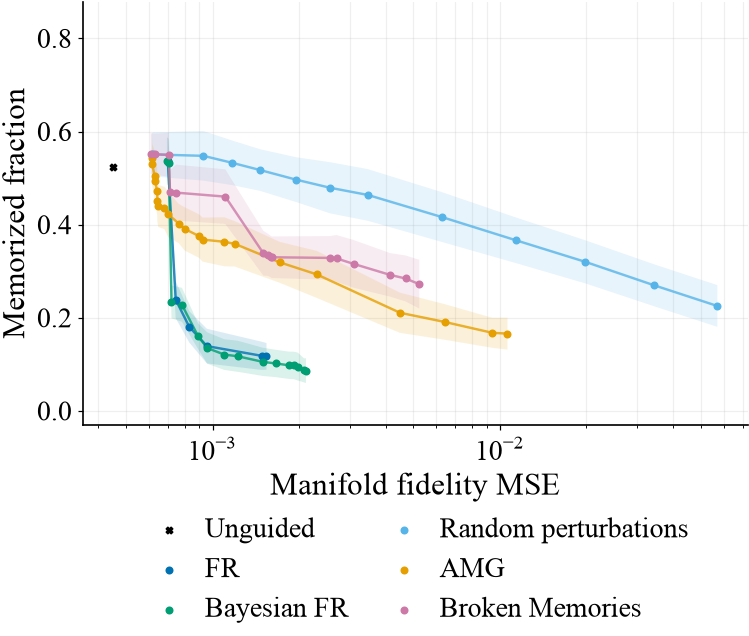

,20
Unguided,Unguided T=1
Ambient FR,Ambient FR eta=0.8 window=0.1
Bayesian Ambient FR,Bayesian Ambient FR eta=0.8 window=0.1 alpha=1
Random perturbations,Random perturbations eta=0.8
AMG,AMG c3=5 window=0.4
Broken Memories,Broken Memories scale=0.01 gamma=2


shown repetition: 38


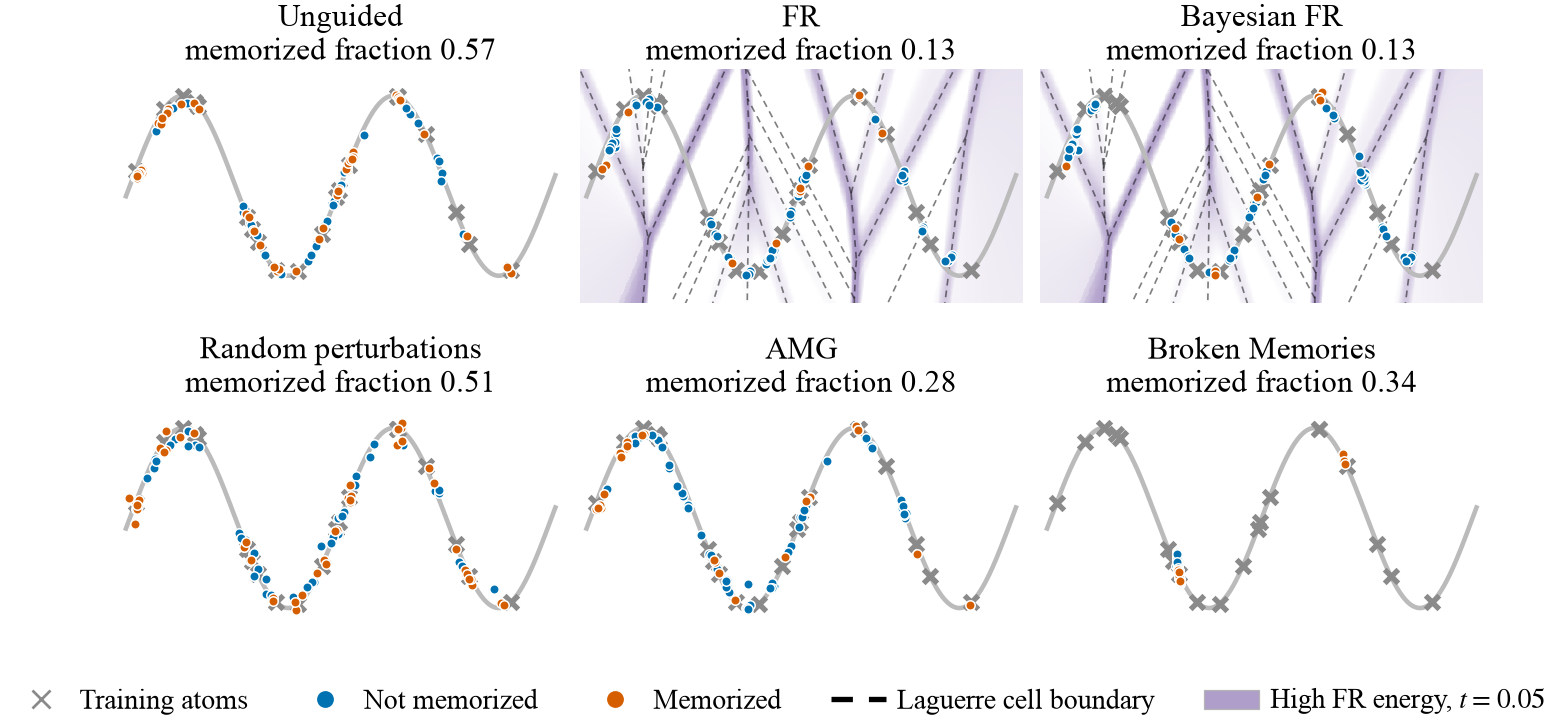

In [5]:
if RUN:
    wsstyle.paper_style()
    FONT = 20
    plt.rcParams.update({'font.size': FONT, 'axes.titlesize': FONT, 'axes.labelsize': FONT, 'figure.titlesize': FONT,
                         'xtick.labelsize': FONT - 2, 'ytick.labelsize': FONT - 2, 'legend.fontsize': FONT - 2})
    KEY = {'Unguided': 'unguided', 'Ambient FR': 'fr', 'Bayesian Ambient FR': 'bayesian_fr', 'Random perturbations': 'random',
           'AMG': 'amg', 'Broken Memories': 'bm'}
    colors = {family: wsstyle.METHOD_COLORS[key] for family, key in KEY.items()}
    labels = {family: wsstyle.METHOD_LABELS[key] for family, key in KEY.items()}
    labels['Unguided'] = 'Unguided'
    def pareto(curve):
        x,y=curve.fidelity_mse_mean.to_numpy(),curve.memorized_fraction_mean.to_numpy()
        dominated=[((x<=xi)&(y<=yi)&((x<xi)|(y<yi))).any() for xi,yi in zip(x,y)]
        return curve[~np.array(dominated)].sort_values('fidelity_mse_mean')
    for N in N_VALUES:
        part=summary[summary.N.eq(N)]
        fig,ax=plt.subplots(figsize=(wsstyle.HALF_WIDTH,7.4))
        for family in colors:
            curve=part[part.family.eq(family)]
            curve=pareto(curve[curve.sweep.ne('paper')])
            top=3*(family=='Unguided'); ax.plot(curve.fidelity_mse_mean,curve.memorized_fraction_mean,color=colors[family],lw=1.6,alpha=.8,zorder=2+top)
            x=curve.fidelity_mse_mean.to_numpy(); y=curve.memorized_fraction_mean.to_numpy(); sd=curve.memorized_fraction_std.to_numpy()
            ax.fill(np.r_[x,x[::-1]],np.r_[np.minimum(1,y+sd),np.maximum(0,y-sd)[::-1]],color=colors[family],lw=0,alpha=.14,zorder=1)
            ax.scatter(curve.fidelity_mse_mean,curve.memorized_fraction_mean,color=colors[family],marker='X' if family=='Unguided' else 'o',s=18,label=labels[family],zorder=3+top)
        ax.set_xscale('log'); ax.set_xlabel('Manifold fidelity MSE'); ax.set_ylabel('Memorized fraction'); ax.set_ylim(-.03,min(1.03,part.memorized_fraction_mean.max()+.06)); wsstyle.grid_on(ax)
        ax.legend(loc='upper center',bbox_to_anchor=(.5,-.16),ncol=2,handletextpad=.3,columnspacing=1); fig.subplots_adjust(bottom=.36)
        wsstyle.save(fig,f'sinusoid_pareto_N{N}'); plt.show()

    def at_fidelity(N, family):
        c = summary[summary.N.eq(N) & summary.family.eq(family) & summary.sweep.ne('paper') & summary.fidelity_mse_mean.le(FIDELITY_BUDGET)]
        if family in ('Ambient FR', 'Bayesian Ambient FR'):
            c = c[c.sweep.str.contains(rf'window={FIGURE_FR_WINDOW:g}(?:,|$)')]
        return c.sort_values(['memorized_fraction_mean', 'fidelity_mse_mean']).iloc[0].method
    fidelity_points = {N: {f: 'Unguided T=1' if f == 'Unguided' else at_fidelity(N, f) for f in KEY} for N in N_VALUES}
    display(pd.DataFrame(fidelity_points))

    from scipy.spatial import Voronoi
    from guidance import basic_fr
    T_FIELD, FR_FAMILIES = 0.05, {'Ambient FR', 'Bayesian Ambient FR'}
    PANELS=[(f,labels[f].split(' (')[0]) for f in ['Unguided','Ambient FR','Bayesian Ambient FR','Random perturbations','AMG','Broken Memories']]
    XLIM,YLIM=(-3.3,3.3),(-.78,.78)

    def fr_field(run, nx=520, ny=200):
        # log10 I(y) at T_FIELD on a grid, with the sampler's k and q_target
        GY,GX=torch.meshgrid(torch.linspace(*YLIM,ny),torch.linspace(*XLIM,nx),indexing='ij'); pts=torch.stack([GX.reshape(-1),GY.reshape(-1)],-1)
        nbrs,sq_d=basic_fr.ann_query(run['target'].cpu(),pts,S.FR_SETTINGS['k_neighbors'])
        beta_t=(1-run['alpha_bar'](torch.tensor(T_FIELD))).clamp_min(1e-4).expand(len(pts))
        I,_,_=basic_fr.fisher_rao_energy(pts,nbrs,beta_t,beta_soft=basic_fr.beta_soft_for(sq_d,S.FR_SETTINGS['q_target']))
        return GX.numpy(),GY.numpy(),np.log10(I.reshape(ny,nx).numpy()+1e-12)

    def cell_boundaries(run):
        # Voronoi ridges of the merged atoms as segments; unbounded ridges run out past the axes
        atoms=run['target'].cpu(); close=run['geometry']['atom_dist']<S.MERGE_RADIUS
        pts=np.stack([atoms[close[i]].mean(0).numpy() for i in range(len(atoms)) if close[i].nonzero()[0].item()==i])
        vor=Voronoi(pts); center=pts.mean(0); segments=[]
        for (p,q),ridge in zip(vor.ridge_points,vor.ridge_vertices):
            if -1 not in ridge: segments.append(vor.vertices[ridge]); continue
            v=vor.vertices[max(ridge)]; tangent=pts[q]-pts[p]; normal=np.array([-tangent[1],tangent[0]])/np.linalg.norm(tangent)
            normal*=np.sign((pts[[p,q]].mean(0)-center)@normal) or 1
            segments.append(np.stack([v,v+20*normal]))
        return segments

    field_cmap=wsstyle.alpha_ramp_cmap(wsstyle.C['field'],alpha_max=.6)
    for N in N_VALUES:
        run=runs[N]; curve=S.manifold(torch.linspace(-run['cfg']['u_range'],run['cfg']['u_range'],500)); target=run['target'].cpu()
        GX,GY,logI=fr_field(run); norm=plt.Normalize(*np.percentile(logI,[45,99])); segments=cell_boundaries(run)
        # one paired repetition for every panel, so no panel gets its own lucky draw
        mem_by_rep=pd.DataFrame({f: raw[raw.N.eq(N)&raw.method.eq(fidelity_points[N][f])].set_index('repetition').memorized_fraction for f,_ in PANELS})
        rep=int(((mem_by_rep-mem_by_rep.mean())/mem_by_rep.std()).abs().sum(axis=1).idxmin()); print('shown repetition:',rep)
        n_panels=len(PANELS); n_cols=3; n_rows=(n_panels+n_cols-1)//n_cols
        fig,axes=plt.subplots(n_rows,n_cols,figsize=(wsstyle.FULL_WIDTH,3.3*n_rows),sharex=True,sharey=True)
        for ax,(family,title) in zip(axes.flat,PANELS):
            if family in FR_FAMILIES:
                ax.pcolormesh(GX,GY,logI,cmap=field_cmap,norm=norm,shading='auto',zorder=-2,rasterized=True)
                for seg in segments: ax.plot(seg[:,0],seg[:,1],color=wsstyle.C['boundary'],ls=(0,(4,3)),lw=1.1,alpha=.5,zorder=-1)
            ax.plot(curve[:,0],curve[:,1],color=wsstyle.C['manifold'],lw=3,zorder=0); ax.scatter(target[:,0],target[:,1],marker='x',color=wsstyle.C['atoms'],s=80,zorder=1)
            method=fidelity_points[N][family]
            x=samples[(N,rep,method)]['x']; mem=S.is_memorized(run,x)
            ax.scatter(x[~mem,0],x[~mem,1],color=wsstyle.C['unmemorized'],s=38,edgecolors='white',zorder=2); ax.scatter(x[mem,0],x[mem,1],color=wsstyle.C['memorized'],s=38,edgecolors='white',zorder=3)
            ax.set_title(f'{title}\nmemorized fraction {mem.float().mean().item():.2f}')
            ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); wsstyle.strip_axes(ax)
        for ax in axes.flat[n_panels:]: ax.axis('off')
        fig.subplots_adjust(wspace=.04,hspace=.42,bottom=.1)
        wsstyle.figure_legend(fig,[('Training atoms','cross',wsstyle.C['atoms']),('Not memorized','point',wsstyle.C['unmemorized']),
                                   ('Memorized','point',wsstyle.C['memorized']),('Laguerre cell boundary','line',wsstyle.C['boundary'],(0,(4,3))),
                                   (rf'High FR energy, $t = {T_FIELD:g}$','patch',wsstyle.blend_on_white(wsstyle.C['field'],.6))],y=.06)
        wsstyle.save(fig,f'sinusoid_final_positions_N{N}'); plt.show()
